In [5]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sobhanmoosavi/us-accidents")

print("Path to dataset files:", path)

100%|██████████| 653M/653M [00:13<00:00, 51.1MB/s] 

Extracting files...


Path to dataset files: /home/aabburi/.cache/kagglehub/datasets/sobhanmoosavi/us-accidents/versions/13


In [1]:
# !cp -r ~/.cache/kagglehub/datasets/sobhanmoosavi/us-accidents/versions/13 .
path = '/home/aabburi/.cache/kagglehub/datasets/sobhanmoosavi/us-accidents/versions/13'
!cp -r "$path/" "input/"

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, average_precision_score, classification_report, roc_curve, precision_recall_curve, auc
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree  # For viz
import xgboost as xgb
from imblearn.over_sampling import SMOTE
import category_encoders as ce  # For TargetEncoder

In [5]:
df = pd.read_csv('input/US_Accidents_March23.csv')  # Full path
sample_size = 1000000
df_sample = df.groupby('Severity', group_keys=False).apply(lambda x: x.sample(min(len(x), sample_size // 4), random_state=42))

/tmp/ipykernel_54088/1423399975.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_sample = df.groupby('Severity', group_keys=False).apply(lambda x: x.sample(min(len(x), sample_size // 4), random_state=42))


In [ ]:
# Derive time (before drop)
df['Start_Time'] = pd.to_datetime(df['Start_Time'], format='mixed')
df['Hour'] = df['Start_Time'].dt.hour
df['Day'] = df['Start_Time'].dt.dayofweek  # 0=Mon
df['Month'] = df['Start_Time'].dt.month

In [6]:
# drop_cols = ['ID', 'Source', 'Description', 'Country', 'End_Lat', 'End_Lng', 'Weather_Timestamp', 'Wind_Chill(F)', 'Precipitation(in)', 'Zipcode', 'Street', 'City']
# df_clean = df_sample.drop(columns=drop_cols)
# Drop leakage/post-outcome (prof: For severity-at-onset)
drop_leak = ['End_Time', 'Distance(mi)']  # Post-accident
drop_other = ['ID', 'Source', 'Description', 'Country', 'End_Lat', 'End_Lng', 
              'Weather_Timestamp', 'Wind_Chill(F)', 'Precipitation(in)']  # High-null/irrelevant
df_clean = df.drop(columns=drop_leak + drop_other + ['Start_Time'])  # Drop after derive

In [10]:
# num_cols = ['Temperature(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Speed(mph)', 'Distance(mi)']
# for col in num_cols:
#     df_clean[col].fillna(df_clean[col].mean(), inplace=True)

# cat_cols = ['County', 'State', 'Timezone', 'Airport_Code', 'Wind_Direction', 'Weather_Condition', 'Sunrise_Sunset']
# for col in cat_cols:
#     df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)
# Nulls (means/modes)
num_cols = ['Temperature(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 
            'Wind_Speed(mph)', 'Start_Lat', 'Start_Lng', 'Hour', 'Day', 'Month']
cat_cols = ['County', 'State', 'Timezone', 'Airport_Code', 'Wind_Direction', 
            'Weather_Condition', 'Sunrise_Sunset', 'Civil_Twilight', 
            'Nautical_Twilight', 'Astronomical_Twilight', 'City', 'Street', 'Zipcode']  # Incl high-card
bool_cols = [col for col in df_clean if df_clean[col].dtype == bool]

for col in num_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mean())
for col in cat_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])
df_clean[bool_cols] = df_clean[bool_cols].astype(int)

/tmp/ipykernel_54088/4102697102.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean[col].fillna(df_clean[col].mean(), inplace=True)
/tmp/ipykernel_54088/4102697102.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tr

In [13]:
# from sklearn.preprocessing import LabelEncoder
# le = LabelEncoder()
# for col in ['State', 'Timezone', 'Wind_Direction', 'Weather_Condition', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight']:
#     df_clean[col] = le.fit_transform(df_clean[col].astype(str))

# # Bools already bool—convert to int if needed: df_clean['Amenity'] = df_clean['Amenity'].astype(int)
# Encode (prof: Careful high-card; Target for all cats—mean Severity per unique)
encoder = ce.TargetEncoder(cols=cat_cols)
df_clean[cat_cols] = encoder.fit_transform(df_clean[cat_cols], df_clean['Severity'])

In [14]:
# from sklearn.preprocessing import StandardScaler
# scaler = StandardScaler()
# df_clean[num_cols + ['Start_Lat', 'Start_Lng']] = scaler.fit_transform(df_clean[num_cols + ['Start_Lat', 'Start_Lng']])
# Scale num (optional for trees, but good practice)
scaler = StandardScaler()
df_clean[num_cols] = scaler.fit_transform(df_clean[num_cols])

In [15]:
# X = df_clean.drop('Severity', axis=1)
# y = df_clean['Severity'] - 1  # 0-3 for multiclass
# X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
# X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)
# Split (stratified)
X = df_clean.drop('Severity', axis=1)
y = df_clean['Severity'] - 1  # 0-3
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [21]:
# Check the data types of the columns in X_train
print(X_train.dtypes)

# Inspect the first few rows of X_train
# print(X_train.head())


Start_Lat                float64
Start_Lng                float64
Distance(mi)             float64
County                     int64
State                      int64
Timezone                   int64
Airport_Code               int64
Temperature(F)           float64
Humidity(%)              float64
Pressure(in)             float64
Visibility(mi)           float64
Wind_Direction             int64
Wind_Speed(mph)          float64
Weather_Condition          int64
Amenity                    int64
Bump                       int64
Crossing                   int64
Give_Way                   int64
Junction                   int64
No_Exit                    int64
Railway                    int64
Roundabout                 int64
Station                    int64
Stop                       int64
Traffic_Calming            int64
Traffic_Signal             int64
Turning_Loop               int64
Sunrise_Sunset             int64
Civil_Twilight             int64
Nautical_Twilight          int64
Astronomic

In [17]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

ValueError: could not convert string to float: 'Warren'

/tmp/ipykernel_54088/3577929912.py:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df_full.groupby('Severity', group_keys=False).apply(lambda x: x.sample(min(len(x), sample_size // 4), random_state=42))



Without SMOTE:
RF Best Params: {'max_depth': 10}
RF Acc: 0.6861270852761372
RF F1 Macro: 0.6852391274950347
RF AUROC: 0.88601359257484
RF AUPRC: 0.7647628195112609
              precision    recall  f1-score   support

           0       0.82      0.58      0.68     13474
           1       0.70      0.68      0.69     50000
           2       0.63      0.74      0.68     50000
           3       0.73      0.66      0.69     40942

    accuracy                           0.69    154416
   macro avg       0.72      0.67      0.69    154416
weighted avg       0.69      0.69      0.69    154416



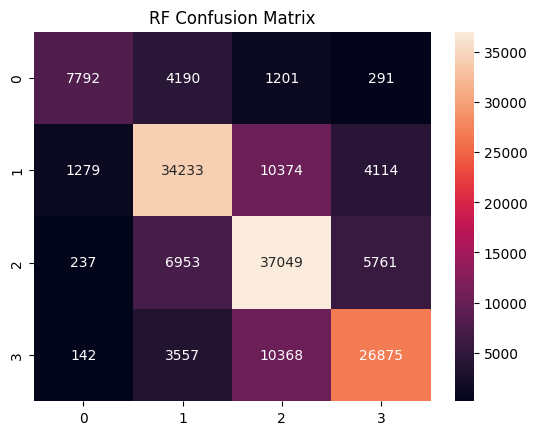

XGB Best Params: {'learning_rate': 0.1, 'max_depth': 6}
XGB Acc: 0.7236879597969123
XGB F1 Macro: 0.7315893459665351
XGB AUROC: 0.914691956193515
XGB AUPRC: 0.8220064583600432
              precision    recall  f1-score   support

           0       0.77      0.77      0.77     13474
           1       0.77      0.68      0.72     50000
           2       0.65      0.79      0.72     50000
           3       0.77      0.68      0.72     40942

    accuracy                           0.72    154416
   macro avg       0.74      0.73      0.73    154416
weighted avg       0.73      0.72      0.72    154416



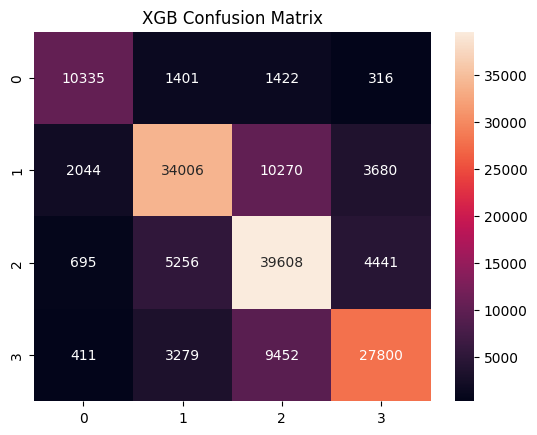


With SMOTE:
RF Best Params: {'max_depth': 10}
RF Acc: 0.6785695782820433
RF F1 Macro: 0.6797884258573139
RF AUROC: 0.8841411048728676
RF AUPRC: 0.7593109337174657
              precision    recall  f1-score   support

           0       0.56      0.86      0.68     13474
           1       0.77      0.61      0.68     50000
           2       0.64      0.69      0.67     50000
           3       0.69      0.69      0.69     40942

    accuracy                           0.68    154416
   macro avg       0.67      0.71      0.68    154416
weighted avg       0.69      0.68      0.68    154416



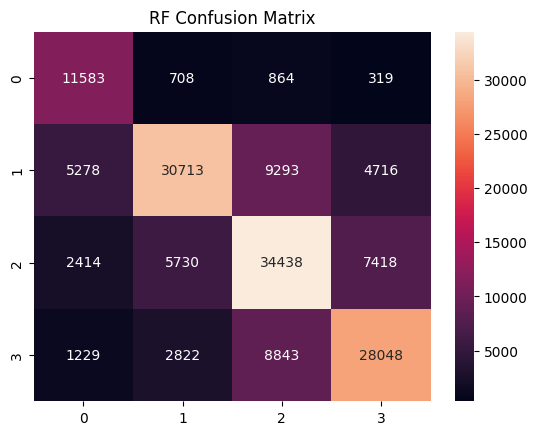

XGB Best Params: {'learning_rate': 0.1, 'max_depth': 6}
XGB Acc: 0.7142459330639312
XGB F1 Macro: 0.7171346483930886
XGB AUROC: 0.911001736217768
XGB AUPRC: 0.8136525570384238
              precision    recall  f1-score   support

           0       0.63      0.86      0.73     13474
           1       0.79      0.64      0.71     50000
           2       0.67      0.75      0.71     50000
           3       0.74      0.70      0.72     40942

    accuracy                           0.71    154416
   macro avg       0.71      0.74      0.72    154416
weighted avg       0.72      0.71      0.71    154416



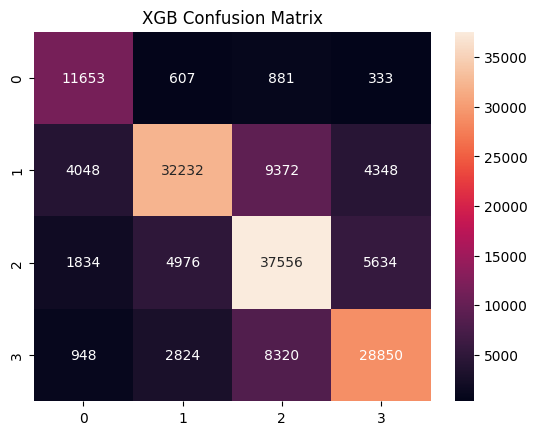

In [23]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, average_precision_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from imblearn.over_sampling import SMOTE
import category_encoders as ce  # For TargetEncoder

# Load your 1M sample (adjust path)
# df = pd.read_csv('input/US_Accidents_Sample.csv')  # From prior
df_full = pd.read_csv('input/US_Accidents_March23.csv')  # Full path
sample_size = 1000000
df = df_full.groupby('Severity', group_keys=False).apply(lambda x: x.sample(min(len(x), sample_size // 4), random_state=42))

# Derive time (before drop)
df['Start_Time'] = pd.to_datetime(df['Start_Time'], format='mixed')
df['Hour'] = df['Start_Time'].dt.hour
df['Day'] = df['Start_Time'].dt.dayofweek  # 0=Mon
df['Month'] = df['Start_Time'].dt.month

# Drop leakage/post-outcome (prof: For severity-at-onset)
drop_leak = ['End_Time', 'Distance(mi)']  # Post-accident
drop_other = ['ID', 'Source', 'Description', 'Country', 'End_Lat', 'End_Lng', 
              'Weather_Timestamp', 'Wind_Chill(F)', 'Precipitation(in)']  # High-null/irrelevant
df_clean = df.drop(columns=drop_leak + drop_other + ['Start_Time'])  # Drop after derive

# Nulls (means/modes)
num_cols = ['Temperature(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 
            'Wind_Speed(mph)', 'Start_Lat', 'Start_Lng', 'Hour', 'Day', 'Month']
cat_cols = ['County', 'State', 'Timezone', 'Airport_Code', 'Wind_Direction', 
            'Weather_Condition', 'Sunrise_Sunset', 'Civil_Twilight', 
            'Nautical_Twilight', 'Astronomical_Twilight', 'City', 'Street', 'Zipcode']  # Incl high-card
bool_cols = [col for col in df_clean if df_clean[col].dtype == bool]

for col in num_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mean())
for col in cat_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])
df_clean[bool_cols] = df_clean[bool_cols].astype(int)

# Encode (prof: Careful high-card; Target for all cats—mean Severity per unique)
encoder = ce.TargetEncoder(cols=cat_cols)
df_clean[cat_cols] = encoder.fit_transform(df_clean[cat_cols], df_clean['Severity'])


# Scale num (optional for trees, but good practice)
scaler = StandardScaler()
df_clean[num_cols] = scaler.fit_transform(df_clean[num_cols])

# Split (stratified)
X = df_clean.drop('Severity', axis=1)
y = df_clean['Severity'] - 1  # 0-3
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Run twice: With/without SMOTE
for use_smote in [False, True]:
    if use_smote:
        smote = SMOTE(random_state=42)
        X_tr, y_tr = smote.fit_resample(X_train, y_train)
        print("\nWith SMOTE:")
    else:
        X_tr, y_tr = X_train, y_train
        print("\nWithout SMOTE:")

    # RF (tune simple)
    rf = RandomForestClassifier(random_state=42)
    grid_rf = GridSearchCV(rf, {'max_depth': [5, 10]}, cv=3, scoring='f1_macro')
    grid_rf.fit(X_tr, y_tr)
    y_pred_rf = grid_rf.predict(X_test)
    print("RF Best Params:", grid_rf.best_params_)
    print("RF Acc:", accuracy_score(y_test, y_pred_rf))
    print("RF F1 Macro:", f1_score(y_test, y_pred_rf, average='macro'))
    print("RF AUROC:", roc_auc_score(y_test, grid_rf.predict_proba(X_test), multi_class='ovr'))
    print("RF AUPRC:", average_precision_score(y_test, grid_rf.predict_proba(X_test), average='macro'))
    print(classification_report(y_test, y_pred_rf))

    # Plot confusion (for slide)
    sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d')
    plt.title('RF Confusion Matrix')
    plt.show()

    # XGB (tune simple)
    xgb_model = xgb.XGBClassifier(random_state=42, objective='multi:softmax', num_class=4)
    grid_xgb = GridSearchCV(xgb_model, {'max_depth': [3, 6], 'learning_rate': [0.1]}, cv=3, scoring='f1_macro')
    grid_xgb.fit(X_tr, y_tr)
    y_pred_xgb = grid_xgb.predict(X_test)
    print("XGB Best Params:", grid_xgb.best_params_)
    print("XGB Acc:", accuracy_score(y_test, y_pred_xgb))
    print("XGB F1 Macro:", f1_score(y_test, y_pred_xgb, average='macro'))
    print("XGB AUROC:", roc_auc_score(y_test, grid_xgb.predict_proba(X_test), multi_class='ovr'))
    print("XGB AUPRC:", average_precision_score(y_test, grid_xgb.predict_proba(X_test), average='macro'))
    print(classification_report(y_test, y_pred_xgb))

    # Plot
    sns.heatmap(confusion_matrix(y_test, y_pred_xgb), annot=True, fmt='d')
    plt.title('XGB Confusion Matrix')
    plt.show()

## Random Forest and XGBoost - Tweaking Hyper parameters

Implementing both Random Forest and XGBoost and choosing the best hyper parameter and encoding and SMOTE.

RF Hyper Table saved
RF Best Params: {'max_depth': 10, 'n_estimators': 100}
Acc: 0.8061599834214072, F1: 0.8148860216245454, AUROC: 0.9502954200330794, AUPRC: 0.8926793697159701
              precision    recall  f1-score   support

           0       0.92      0.81      0.86     13474
           1       0.79      0.78      0.79     50000
           2       0.84      0.84      0.84     50000
           3       0.75      0.80      0.77     40942

    accuracy                           0.81    154416
   macro avg       0.83      0.81      0.81    154416
weighted avg       0.81      0.81      0.81    154416



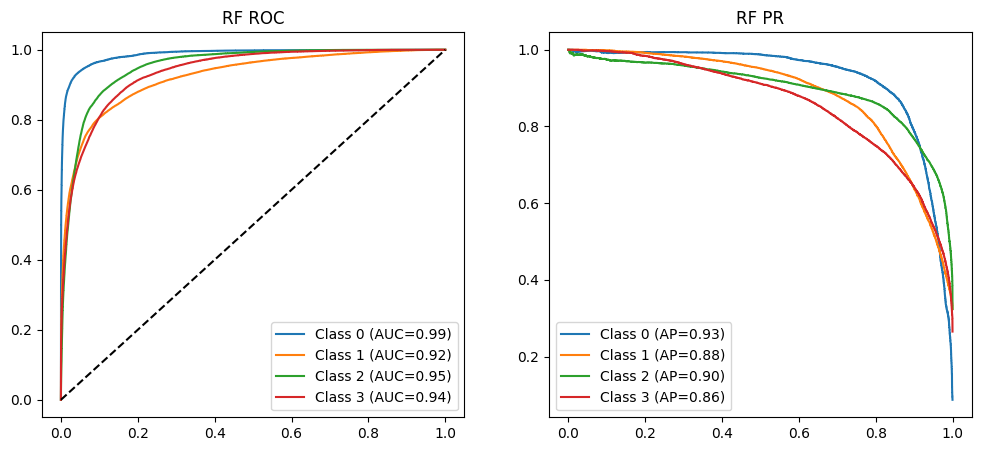

XGB Hyper Table saved
XGB Best Params: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200}
Acc: 0.8420953787172314, F1: 0.852132669548304, AUROC: 0.9680943384827863, AUPRC: 0.9311338597421634
              precision    recall  f1-score   support

           0       0.88      0.94      0.91     13474
           1       0.86      0.81      0.84     50000
           2       0.84      0.89      0.86     50000
           3       0.81      0.79      0.80     40942

    accuracy                           0.84    154416
   macro avg       0.85      0.86      0.85    154416
weighted avg       0.84      0.84      0.84    154416



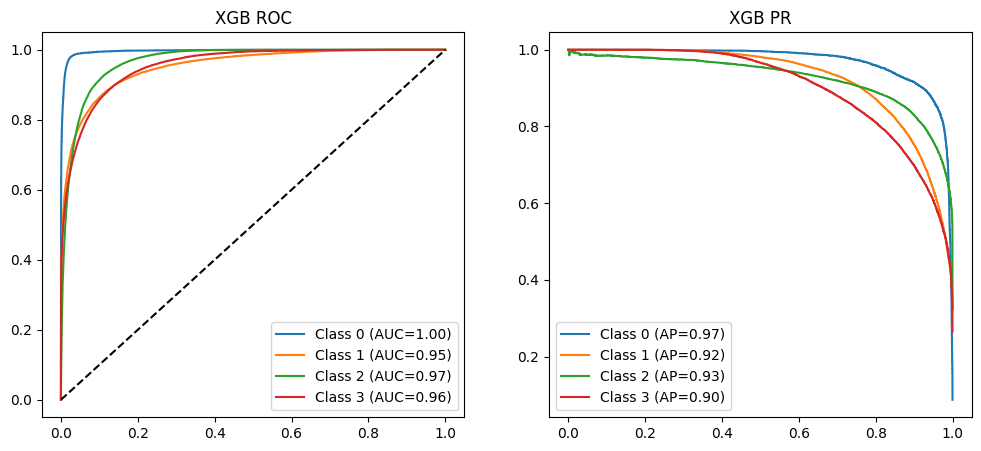

Metrics table saved


AttributeError: 'XGBClassifier' object has no attribute 'estimators_'

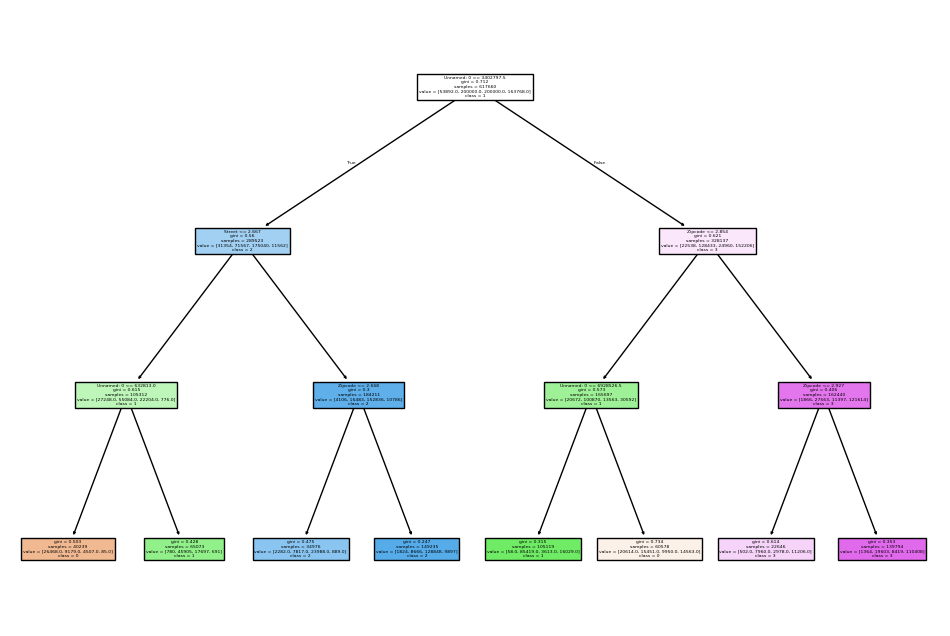

In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, average_precision_score, classification_report, roc_curve, precision_recall_curve, auc
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree  # For viz
import xgboost as xgb
from imblearn.over_sampling import SMOTE
import category_encoders as ce
import numpy as np

# Options (tweak here)
target_encode_all = False  # True: All cats; False: Only high-card (> high_card_thresh uniques)
high_card_thresh = 50  # E.g., City >50 uniques -> target encode
use_smote = False  # Toggle; run manually twice if compare
sample_path = 'input/us-accidents-sample-1M.csv'  # Your 1M stratified

# Load
df = pd.read_csv(sample_path)

# Derive time
df['Start_Time'] = pd.to_datetime(df['Start_Time'], format='mixed')
df['Hour'] = df['Start_Time'].dt.hour
df['Day'] = df['Start_Time'].dt.dayofweek
df['Month'] = df['Start_Time'].dt.month

# Drops (leakage + irrelevant/high-null)
drop_leak = ['End_Time', 'Distance(mi)']
drop_other = ['ID', 'Source', 'Description', 'Country', 'End_Lat', 'End_Lng', 
              'Weather_Timestamp', 'Wind_Chill(F)', 'Precipitation(in)']
df_clean = df.drop(columns=drop_leak + drop_other + ['Start_Time'])

# Nulls
num_cols = ['Temperature(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 
            'Wind_Speed(mph)', 'Start_Lat', 'Start_Lng', 'Hour', 'Day', 'Month']
cat_cols = ['County', 'State', 'Timezone', 'Airport_Code', 'Wind_Direction', 
            'Weather_Condition', 'Sunrise_Sunset', 'Civil_Twilight', 
            'Nautical_Twilight', 'Astronomical_Twilight', 'City', 'Street', 'Zipcode']
bool_cols = [col for col in df_clean if df_clean[col].dtype == bool]

for col in num_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mean())
for col in cat_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])
df_clean[bool_cols] = df_clean[bool_cols].astype(int)

# Encode (target for high/all)
if target_encode_all:
    encoder = ce.TargetEncoder(cols=cat_cols)
    df_clean[cat_cols] = encoder.fit_transform(df_clean[cat_cols], df_clean['Severity'])
else:
    high_card_cols = [col for col in cat_cols if df_clean[col].nunique() > high_card_thresh]
    encoder = ce.TargetEncoder(cols=high_card_cols)
    df_clean[high_card_cols] = encoder.fit_transform(df_clean[high_card_cols], df_clean['Severity'])
    
    # Now encode lows with Label
    low_card_cols = list(set(cat_cols) - set(high_card_cols))
    le_dict = {}
    for col in low_card_cols:
        le = LabelEncoder()
        df_clean[col] = le.fit_transform(df_clean[col].astype(str))
        le_dict[col] = le

# Scale
scaler = StandardScaler()
df_clean[num_cols] = scaler.fit_transform(df_clean[num_cols])

# Split
X = df_clean.drop('Severity', axis=1)
y = df_clean['Severity'] - 1
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# SMOTE if
if use_smote:
    smote = SMOTE(random_state=42)
    X_tr, y_tr = smote.fit_resample(X_train, y_train)
else:
    X_tr, y_tr = X_train, y_train

# Models + Grid (explore hypers)
models = {'RF': RandomForestClassifier(random_state=42),
          'XGB': xgb.XGBClassifier(random_state=42, objective='multi:softmax', num_class=4)}
params = {'RF': {'max_depth': [3, 5, 10], 'n_estimators': [100, 200]},
          'XGB': {'max_depth': [3, 5, 6], 'learning_rate': [0.01, 0.1], 'n_estimators': [100, 200]}}

results = []  # For table
for name, model in models.items():
    grid = GridSearchCV(model, params[name], cv=5, scoring='f1_macro')
    grid.fit(X_tr, y_tr)
    
    # Table row
    cv_res = pd.DataFrame(grid.cv_results_)[['params', 'mean_test_score', 'std_test_score']]
    cv_res.to_csv(f'{name}_hyper_table.csv', index=False)  # For PPT
    print(f'{name} Hyper Table saved')
    
    # Best
    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')
    auroc = roc_auc_score(y_test, best_model.predict_proba(X_test), multi_class='ovr')
    auprc = average_precision_score(y_test, best_model.predict_proba(X_test), average='macro')
    print(f'{name} Best Params: {grid.best_params_}')
    print(f'Acc: {acc}, F1: {f1}, AUROC: {auroc}, AUPRC: {auprc}')
    print(classification_report(y_test, y_pred))
    
    results.append({'Model': name, 'Acc': acc, 'F1': f1, 'AUROC': auroc, 'AUPRC': auprc})
    
    # Graphs (ROC/PR per class)
    y_prob = best_model.predict_proba(X_test)
    n_classes = len(np.unique(y_test))
    f, ax = plt.subplots(1, 2, figsize=(12, 5))
    
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve((y_test == i).astype(int), y_prob[:, i])
        ax[0].plot(fpr, tpr, label=f'Class {i} (AUC={auc(fpr, tpr):.2f})')
    ax[0].plot([0,1],[0,1],'k--')
    ax[0].set_title(f'{name} ROC')
    ax[0].legend()
    
    for i in range(n_classes):
        prec, rec, _ = precision_recall_curve((y_test == i).astype(int), y_prob[:, i])
        ax[1].plot(rec, prec, label=f'Class {i} (AP={average_precision_score((y_test == i).astype(int), y_prob[:, i]):.2f})')
    ax[1].set_title(f'{name} PR')
    ax[1].legend()
    plt.savefig(f'{name}_curves.png')
    plt.show()

# Overall table
pd.DataFrame(results).to_csv('metrics_table.csv', index=False)
print('Metrics table saved')

# Tree Viz (1-2 for PPT; standalone + one from RF)
dt = DecisionTreeClassifier(max_depth=3, random_state=42).fit(X_tr, y_tr)
plt.figure(figsize=(12,8))
plot_tree(dt, feature_names=X.columns, class_names=[str(i) for i in np.unique(y_tr)], filled=True)
plt.savefig('dt_viz.png')

rf_tree = best_model.estimators_[0] if 'RF' in models else None  # One from RF
if rf_tree:
    plt.figure(figsize=(12,8))
    plot_tree(rf_tree, feature_names=X.columns, class_names=[str(i) for i in np.unique(y_tr)], filled=True)
    plt.savefig('rf_tree_viz.png')

RF Hyper Table saved
RF Best Params: {'max_depth': 10, 'n_estimators': 200}
Acc: 0.7267446378613616, F1: 0.7290278045056833, AUROC: 0.9146320318339624, AUPRC: 0.808247844596354
              precision    recall  f1-score   support

           0       0.90      0.65      0.75     13474
           1       0.69      0.67      0.68     50000
           2       0.74      0.84      0.79     50000
           3       0.70      0.69      0.70     40942

    accuracy                           0.73    154416
   macro avg       0.76      0.71      0.73    154416
weighted avg       0.73      0.73      0.73    154416



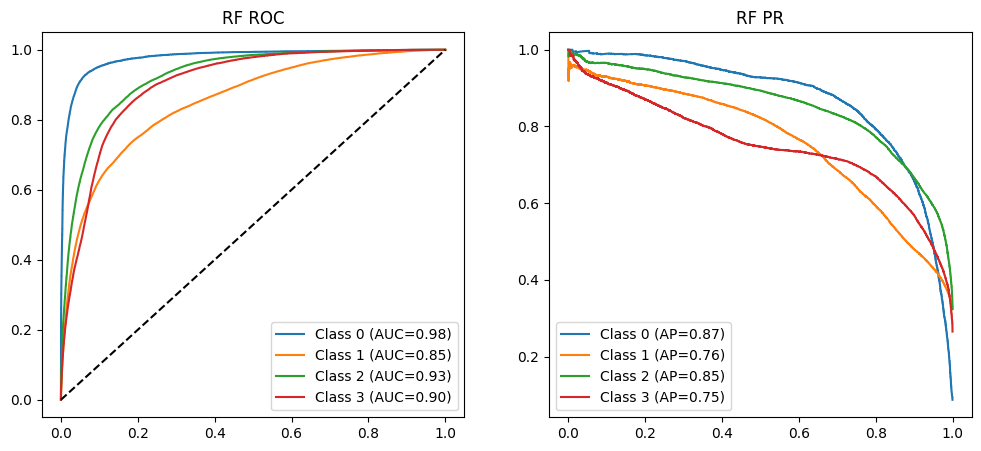

XGB Hyper Table saved
XGB Best Params: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200}
Acc: 0.7553750906641798, F1: 0.7675671541181134, AUROC: 0.9287344096076231, AUPRC: 0.8335495091848484
              precision    recall  f1-score   support

           0       0.85      0.84      0.85     13474
           1       0.73      0.69      0.71     50000
           2       0.76      0.87      0.81     50000
           3       0.74      0.66      0.70     40942

    accuracy                           0.76    154416
   macro avg       0.77      0.77      0.77    154416
weighted avg       0.75      0.76      0.75    154416



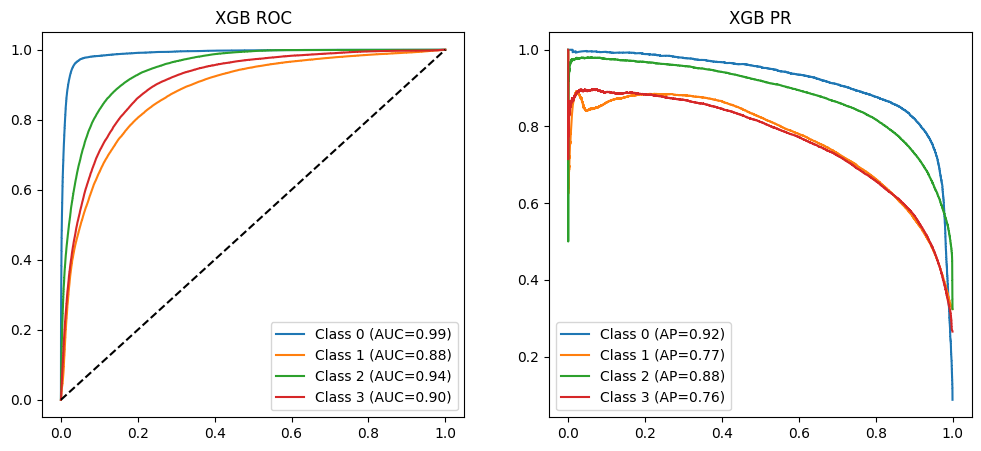

Metrics table saved


AttributeError: 'XGBClassifier' object has no attribute 'estimators_'

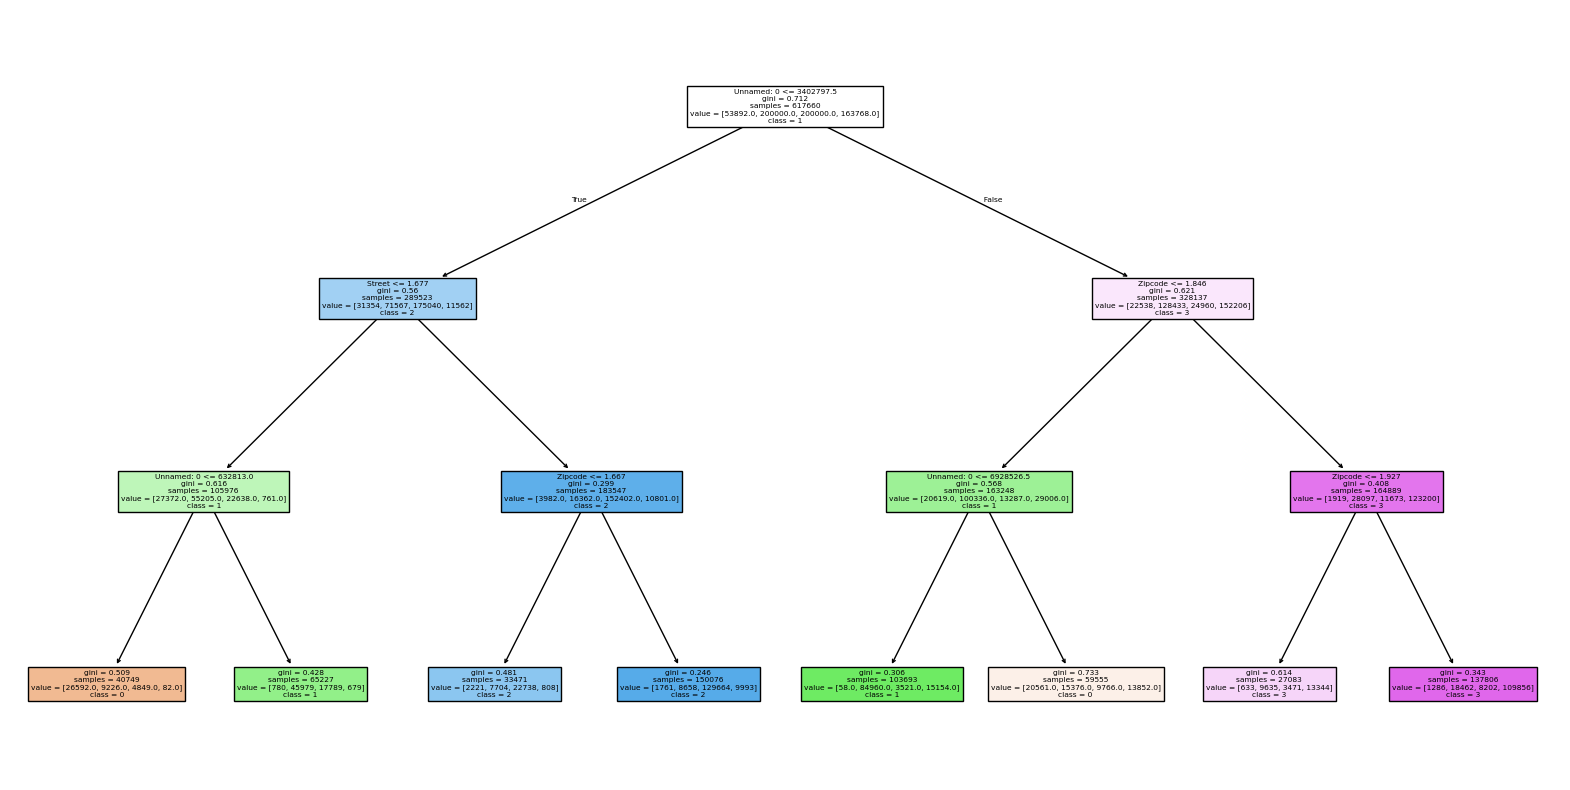

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, average_precision_score, classification_report, roc_curve, precision_recall_curve, auc
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
import xgboost as xgb
from imblearn.over_sampling import SMOTE
import category_encoders as ce
import numpy as np

# Options
target_encode_all = False  # False: Target high, label low
high_card_thresh = 50
use_smote = False
sample_path = 'input/us-accidents-sample-1M.csv'

# Load
df = pd.read_csv(sample_path)

# Derive
df['Start_Time'] = pd.to_datetime(df['Start_Time'], format='mixed')
df['Hour'] = df['Start_Time'].dt.hour
df['Day'] = df['Start_Time'].dt.dayofweek
df['Month'] = df['Start_Time'].dt.month

# Drops
drop_leak = ['End_Time', 'Distance(mi)']
drop_other = ['ID', 'Source', 'Description', 'Country', 'End_Lat', 'End_Lng', 
              'Weather_Timestamp', 'Wind_Chill(F)', 'Precipitation(in)']
df_clean = df.drop(columns=drop_leak + drop_other + ['Start_Time'])

# Nulls (before split ok, no target)
num_cols = ['Temperature(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 
            'Wind_Speed(mph)', 'Start_Lat', 'Start_Lng', 'Hour', 'Day', 'Month']
cat_cols = ['County', 'State', 'Timezone', 'Airport_Code', 'Wind_Direction', 
            'Weather_Condition', 'Sunrise_Sunset', 'Civil_Twilight', 
            'Nautical_Twilight', 'Astronomical_Twilight', 'City', 'Street', 'Zipcode']
bool_cols = [col for col in df_clean if df_clean[col].dtype == bool]

for col in num_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mean())
for col in cat_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])
df_clean[bool_cols] = df_clean[bool_cols].astype(int)

# Split first (anti-leakage)
X = df_clean.drop('Severity', axis=1)
y = df_clean['Severity'] - 1
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Encode after split (fit train)
if target_encode_all:
    encoder = ce.TargetEncoder(cols=cat_cols)
    X_train[cat_cols] = encoder.fit_transform(X_train[cat_cols], y_train)
    X_test[cat_cols] = encoder.transform(X_test[cat_cols])
else:
    high_card_cols = [col for col in cat_cols if X_train[col].nunique() > high_card_thresh]
    encoder = ce.TargetEncoder(cols=high_card_cols)
    X_train[high_card_cols] = encoder.fit_transform(X_train[high_card_cols], y_train)
    X_test[high_card_cols] = encoder.transform(X_test[high_card_cols])
    
    low_card_cols = list(set(cat_cols) - set(high_card_cols))
    le_dict = {}
    for col in low_card_cols:
        le = LabelEncoder()
        X_train[col] = le.fit_transform(X_train[col].astype(str))
        X_test[col] = le.transform(X_test[col].astype(str))
        le_dict[col] = le

# Scale after
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

# SMOTE
if use_smote:
    smote = SMOTE(random_state=42)
    X_tr, y_tr = smote.fit_resample(X_train, y_train)
else:
    X_tr, y_tr = X_train, y_train

# Models/grid
models = {'RF': RandomForestClassifier(random_state=42),
          'XGB': xgb.XGBClassifier(random_state=42, objective='multi:softmax', num_class=4)}
params = {'RF': {'max_depth': [3, 5, 10], 'n_estimators': [100, 200]},
          'XGB': {'max_depth': [3, 5, 6], 'learning_rate': [0.01, 0.1], 'n_estimators': [100, 200]}}

results = []
for name, model in models.items():
    grid = GridSearchCV(model, params[name], cv=5, scoring='f1_macro')
    grid.fit(X_tr, y_tr)
    
    cv_res = pd.DataFrame(grid.cv_results_)[['params', 'mean_test_score', 'std_test_score']]
    cv_res.to_csv(f'{name}_hyper_table.csv', index=False)
    print(f'{name} Hyper Table saved')
    
    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')
    auroc = roc_auc_score(y_test, best_model.predict_proba(X_test), multi_class='ovr')
    auprc = average_precision_score(y_test, best_model.predict_proba(X_test), average='macro')
    print(f'{name} Best Params: {grid.best_params_}')
    print(f'Acc: {acc}, F1: {f1}, AUROC: {auroc}, AUPRC: {auprc}')
    print(classification_report(y_test, y_pred))
    
    results.append({'Model': name, 'Acc': acc, 'F1': f1, 'AUROC': auroc, 'AUPRC': auprc})
    
    # Curves
    y_prob = best_model.predict_proba(X_test)
    n_classes = len(np.unique(y_test))
    f, ax = plt.subplots(1, 2, figsize=(12, 5))
    
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve((y_test == i).astype(int), y_prob[:, i])
        ax[0].plot(fpr, tpr, label=f'Class {i} (AUC={auc(fpr, tpr):.2f})')
    ax[0].plot([0,1],[0,1],'k--')
    ax[0].set_title(f'{name} ROC')
    ax[0].legend()
    
    for i in range(n_classes):
        prec, rec, _ = precision_recall_curve((y_test == i).astype(int), y_prob[:, i])
        ax[1].plot(rec, prec, label=f'Class {i} (AP={average_precision_score((y_test == i).astype(int), y_prob[:, i]):.2f})')
    ax[1].set_title(f'{name} PR')
    ax[1].legend()
    plt.savefig(f'{name}_curves.png')
    plt.show()

# Metrics table
pd.DataFrame(results).to_csv('metrics_table.csv', index=False)
print('Metrics table saved')

# Tree viz (larger for clarity; PDF export)
dt = DecisionTreeClassifier(max_depth=3, random_state=42).fit(X_tr, y_tr)
plt.figure(figsize=(20,10))  # Larger
plot_tree(dt, feature_names=X.columns, class_names=[str(i) for i in np.unique(y_tr)], filled=True)
plt.savefig('dt_viz.pdf')  # Vector PDF

# RF tree (one estimator)
if 'RF' in models:
    rf_tree = grid.best_estimator_.estimators_[0]
    plt.figure(figsize=(20,10))
    plot_tree(rf_tree, feature_names=X.columns, class_names=[str(i) for i in np.unique(y_tr)], filled=True)
    plt.savefig('rf_tree_viz.pdf')

# XGB tree (one booster)
if 'XGB' in models:
    xgb.plot_tree(grid.best_estimator_, num_trees=0, rankdir='LR')  # Horizontal
    plt.gcf().set_size_inches(20, 10)
    plt.savefig('xgb_tree_viz.pdf')